In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import itertools
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors

---

---

# LOSSES COMPARISON

In [15]:
# def plot_losses(loss_data):
#     # Unwrap the dictionary if it's stored inside a NumPy 0D array
#     if isinstance(loss_data, np.ndarray):
#         loss_data = loss_data.item()

#     # Determine epochs starting from 1 up to N
#     num_epochs = len(loss_data['train_loss'])
#     epochs = range(1, num_epochs + 1)

#     # Setup figure
#     plt.figure(figsize=(8, 5))

#     # Plot each loss metric
#     plt.plot(epochs, loss_data['train_loss'], label='Train Loss', marker='o')
#     plt.plot(epochs, loss_data['val_loss'], label='Validation Loss', marker='s')
#     plt.plot(epochs, loss_data['test_loss'], label='Test Loss', marker='^')

#     # Formatting
#     plt.title('Training, Validation, and Test Loss over Epochs', fontsize=12, fontweight='bold')
#     plt.xlabel('Epoch', fontsize=11)
#     plt.ylabel('Loss', fontsize=11)
#     plt.xticks(epochs)  # Show integer ticks for all epochs
#     plt.grid(True, linestyle='--', alpha=0.6)
#     plt.legend(frameon=True)
#     plt.tight_layout()

#     plt.show()

In [3]:
# losses = np.load("./checkpoints/sl96_pl96_dm64_el2_tk5/loss_history.npy", allow_pickle=True)

# plot_losses(losses)

In [4]:
# losses = np.load("./checkpoints/TCN_sl96_pl96_dm64_el2_tk5/loss_history.npy", allow_pickle=True)

# plot_losses(losses)

In [28]:
def plot_losses_all(
    ax,
    loss_data,
    title="",
    show_legend=False,
    show_ylabel=False,
    show_xlabel=False,
):
    if isinstance(loss_data, np.ndarray):
        loss_data = loss_data.item()

    num_epochs = len(loss_data["train_loss"])
    epochs = np.arange(1, num_epochs + 1)

    ax.plot(epochs, loss_data["train_loss"], label="Train Loss", marker="o")
    ax.plot(epochs, loss_data["val_loss"], label="Validation Loss", marker="s")
    ax.plot(epochs, loss_data["test_loss"], label="Test Loss", marker="^")

    ax.set_title(title, fontsize=12, fontweight="bold")

    if show_xlabel:
        ax.set_xlabel("Epoch", fontsize=12)
    if show_ylabel:
        ax.set_ylabel("Loss", fontsize=12)

    # Vector 1-10 on x-axis across all plots
    ax.set_xticks(np.arange(1, 11))
    ax.set_xlim(0.5, 10.5)

    ax.grid(True, linestyle="--", alpha=0.6)

    if show_legend:
        ax.legend(frameon=True, fontsize=12)

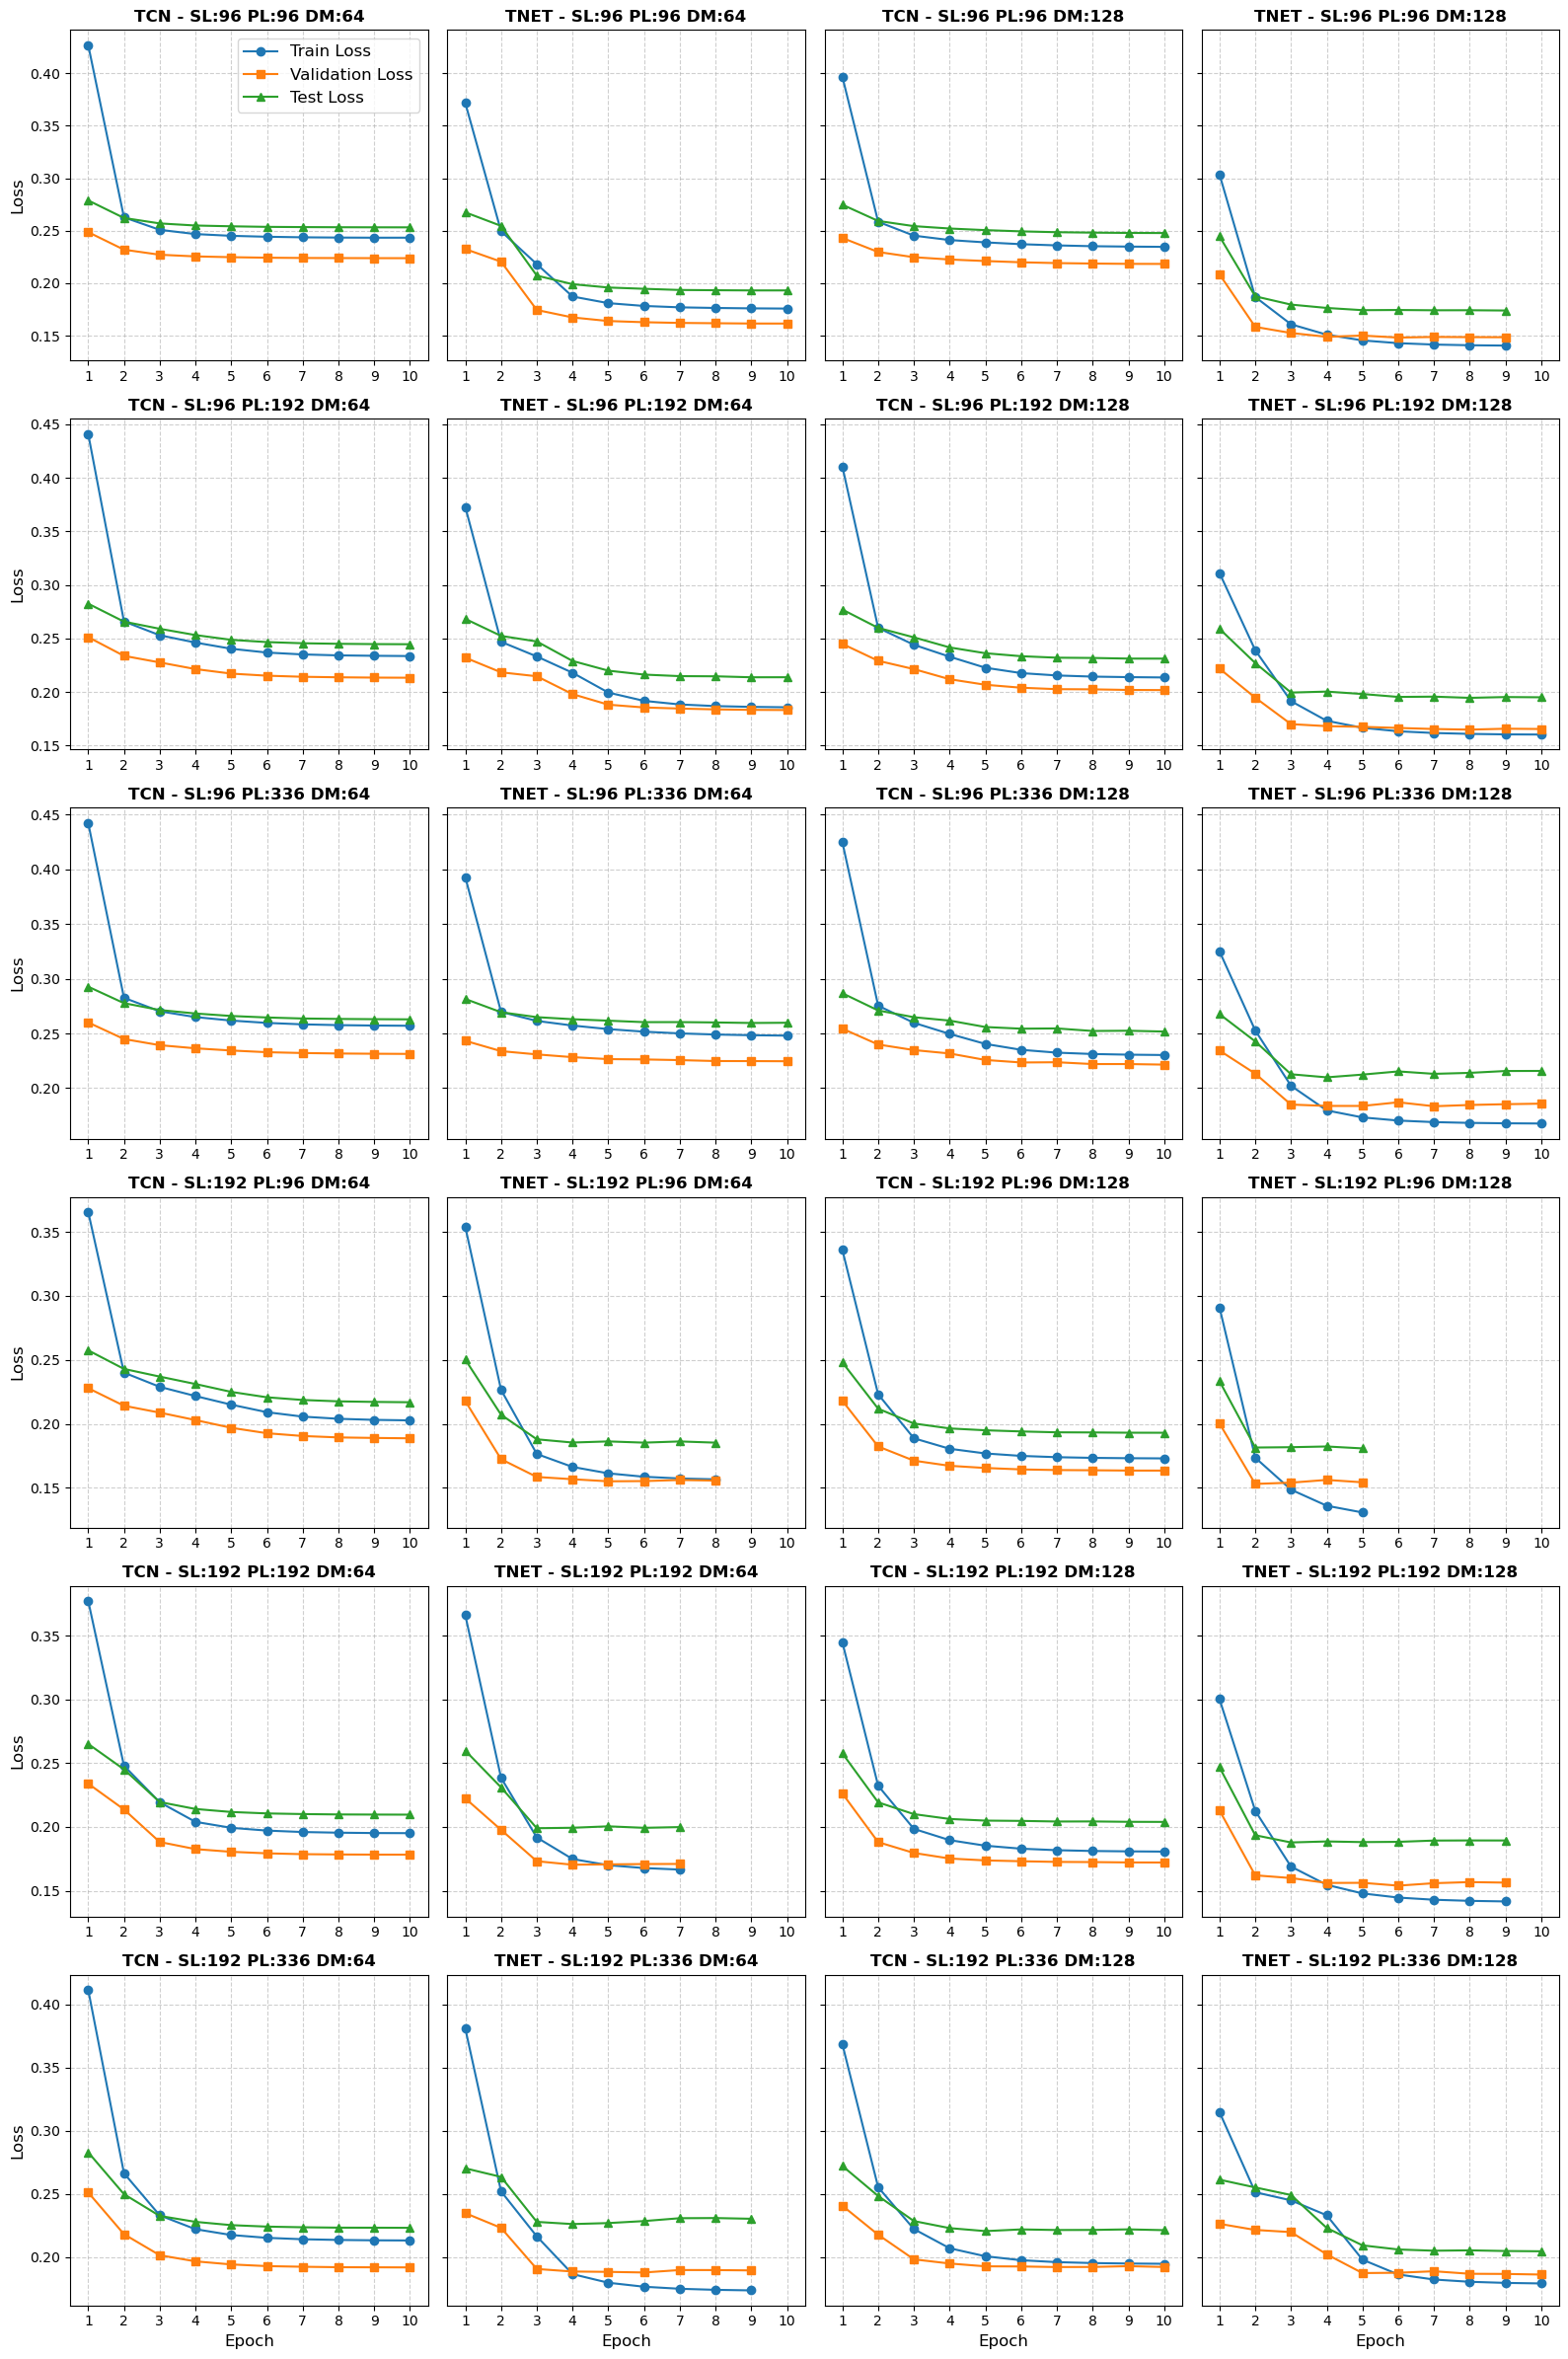

In [29]:
seq_lengths = [96, 192]
pred_lengths = [96, 192, 336]
d_models = [64, 128]

# Create all pairs of hyperparams sl-pl (rows)
param_pairs = list(itertools.product(seq_lengths, pred_lengths))
num_rows = len(param_pairs)

# Models and d_models configuration for the 4 columns
# Col 0: TCN (dm=64), Col 1: TNET (dm=64), Col 2: TCN (dm=128), Col 3: TNET (dm=128)
models = [("TCN", "TCN"), ("TimesNet", "TNET")]
col_configs = []
for dm in d_models:
    for model_folder, label in models:
        col_configs.append((model_folder, label, dm))

num_cols = len(col_configs)  # 4 columns

# Create subplots sharing y-axis across each row
fig, axs = plt.subplots(
    num_rows, num_cols, figsize=(16, 4 * num_rows), sharey="row"
)

# Ensure axs is a 2D array even if num_rows == 1
if num_rows == 1:
    axs = np.expand_dims(axs, axis=0)

for r, (sl, pl) in enumerate(param_pairs):
    is_bottom_row = r == num_rows - 1

    for c, (model_folder, label, dm) in enumerate(col_configs):
        ax = axs[r, c]
        is_leftmost_col = c == 0
        is_first_plot = r == 0 and c == 0

        path = f"./checkpoints/{model_folder}_sl{sl}_pl{pl}_dm{dm}_el2_tk5/loss_history.npy"

        try:
            losses = np.load(path, allow_pickle=True)
            plot_losses_all(
                ax,
                losses,
                title=f"{label} - SL:{sl} PL:{pl} DM:{dm}",
                show_legend=is_first_plot,
                show_ylabel=is_leftmost_col,
                show_xlabel=is_bottom_row,
            )
        except FileNotFoundError:
            ax.set_title(
                f"Missing {label} (SL:{sl}, PL:{pl}, DM:{dm})",
                fontsize=8,
                color="red",
            )
            ax.set_xticks(np.arange(1, 11))
            ax.set_xlim(0.5, 10.5)

            if is_leftmost_col:
                ax.set_ylabel("Loss", fontsize=12)
            if is_bottom_row:
                ax.set_xlabel("Epoch", fontsize=12)

plt.tight_layout()
plt.show()

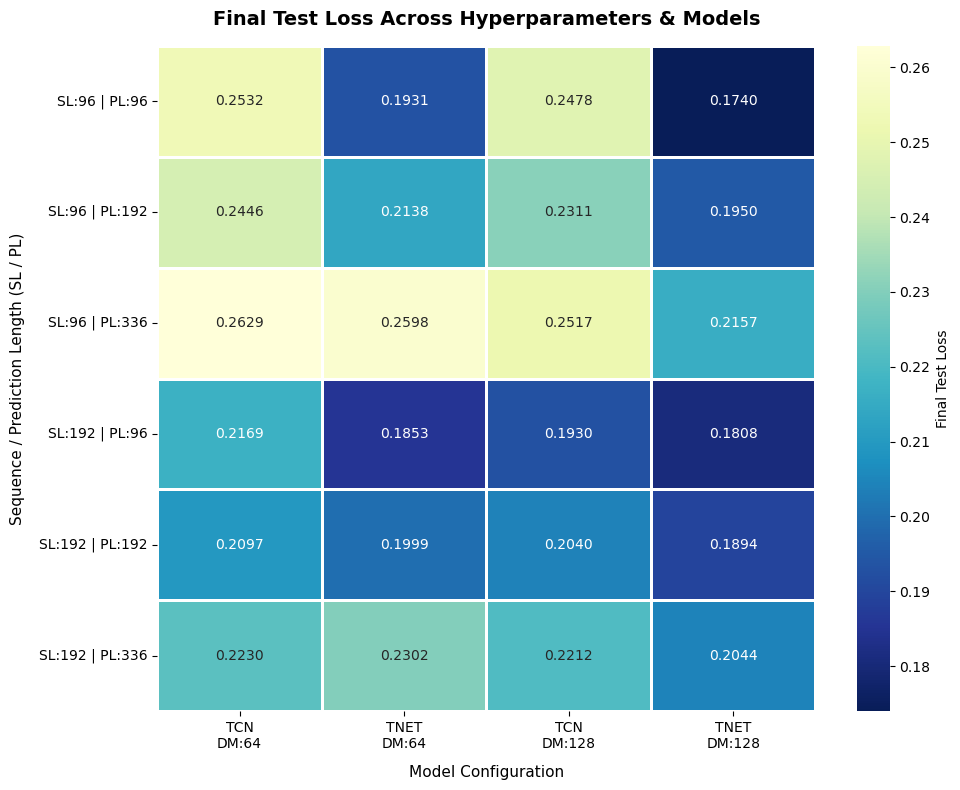

In [32]:
# --- Parameters ---
seq_lengths = [96, 192]
pred_lengths = [96, 192, 336]
d_models = [64, 128]

models = [("TCN", "TCN"), ("TimesNet", "TNET")]

# 1. Generate Row and Column structure
param_pairs = list(itertools.product(seq_lengths, pred_lengths))  # 6 rows
col_configs = []  # 4 columns: TCN-64, TNET-64, TCN-128, TNET-128
for dm in d_models:
    for model_folder, label in models:
        col_configs.append((model_folder, label, dm))

num_rows = len(param_pairs)
num_cols = len(col_configs)

# 2. Extract final test loss values into a 2D matrix
loss_matrix = np.full((num_rows, num_cols), np.nan)

for r, (sl, pl) in enumerate(param_pairs):
    for c, (model_folder, label, dm) in enumerate(col_configs):
        path = f"./checkpoints/{model_folder}_sl{sl}_pl{pl}_dm{dm}_el2_tk5/loss_history.npy"
        try:
            losses = np.load(path, allow_pickle=True)
            if isinstance(losses, np.ndarray):
                losses = losses.item()

            # Take the LAST value of the test loss
            final_test_loss = losses["test_loss"][-1]
            loss_matrix[r, c] = final_test_loss
        except (FileNotFoundError, KeyError, IndexError):
            loss_matrix[r, c] = np.nan  # Leave NaN if file or key is missing

# 3. Build Axis Labels
row_labels = [f"SL:{sl} | PL:{pl}" for sl, pl in param_pairs]
col_labels = [f"{label}\nDM:{dm}" for _, label, dm in col_configs]

# 4. Plot the 2D Heatmap
plt.figure(figsize=(10, 8))

# Use seaborn heatmap for automatic annotations and colorbar formatting
ax = sns.heatmap(
    loss_matrix,
    annot=True,  # Write the numerical loss inside each cell
    fmt=".4f",  # Format as floating point with 4 decimal places
    cmap="YlGnBu_r",  # Reversed color map: darker/greener = lower (better) loss
    xticklabels=col_labels,
    yticklabels=row_labels,
    cbar_kws={"label": "Final Test Loss"},
    linewidths=1,
    linecolor="white",
    mask=np.isnan(
        loss_matrix
    ),  # Mask NaN cells (missing checkpoints will show grey/blank)
)

plt.title(
    "Final Test Loss Across Hyperparameters & Models",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Model Configuration", fontsize=11, labelpad=10)
plt.ylabel("Sequence / Prediction Length (SL / PL)", fontsize=11, labelpad=10)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

/tmp/ipykernel_10550/1769557245.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlGnBu_r")  # Cooler/darker green-blue for low loss
/tmp/ipykernel_10550/1769557245.py:103: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


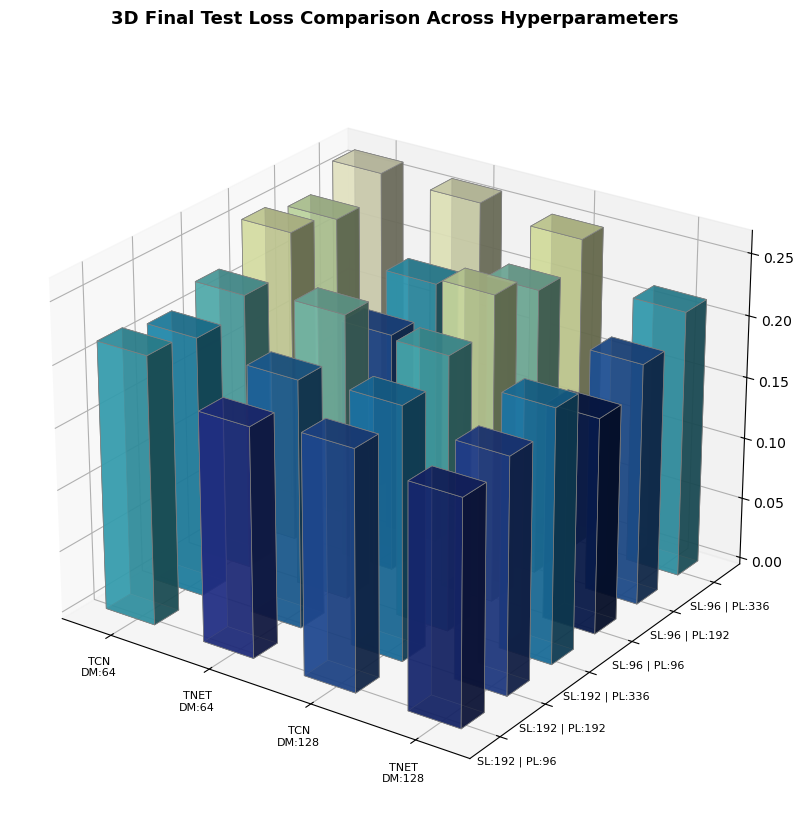

In [39]:
# --- Parameters (Reversed order for SL and PL to keep lowest values in front) ---
seq_lengths = [192, 96]
pred_lengths = [96, 192, 336]
d_models = [64, 128]

models = [("TCN", "TCN"), ("TimesNet", "TNET")]

# 1. Generate Row and Column structure
param_pairs = list(itertools.product(seq_lengths, pred_lengths))  # 6 rows
col_configs = []  # 4 columns: TCN-64, TNET-64, TCN-128, TNET-128
for dm in d_models:
    for model_folder, label in models:
        col_configs.append((model_folder, label, dm))

num_rows = len(param_pairs)
num_cols = len(col_configs)

# 2. Extract final test loss values into a 2D matrix
loss_matrix = np.full((num_rows, num_cols), np.nan)

for r, (sl, pl) in enumerate(param_pairs):
    for c, (model_folder, label, dm) in enumerate(col_configs):
        path = f"./checkpoints/{model_folder}_sl{sl}_pl{pl}_dm{dm}_el2_tk5/loss_history.npy"
        try:
            losses = np.load(path, allow_pickle=True)
            if isinstance(losses, np.ndarray):
                losses = losses.item()

            # Extract last test loss
            final_test_loss = losses["test_loss"][-1]
            loss_matrix[r, c] = final_test_loss
        except (FileNotFoundError, KeyError, IndexError):
            loss_matrix[r, c] = np.nan

# 3. Setup 3D Plot Data
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

# Meshgrid for base positions (X = Columns/Models, Y = Rows/Hyperparams)
_x = np.arange(num_cols)
_y = np.arange(num_rows)
_xx, _yy = np.meshgrid(_x, _y)

xpos = _xx.ravel()
ypos = _yy.ravel()
zpos = np.zeros_like(xpos)

# Bar dimensions
dx = 0.5 * np.ones_like(zpos)
dy = 0.5 * np.ones_like(zpos)
dz = np.nan_to_num(
    loss_matrix.ravel(), nan=0.0
)  # Convert NaNs to 0 height for missing data

# Color map mapping based on height (loss magnitude)
norm = mcolors.Normalize(
    vmin=np.nanmin(loss_matrix), vmax=np.nanmax(loss_matrix)
)
cmap = cm.get_cmap("YlGnBu_r")  # Cooler/darker green-blue for low loss
colors = cmap(norm(dz))

# Apply transparency (alpha = 0.75) to prevent complete occlusion
for i in range(len(colors)):
    if np.isnan(loss_matrix.ravel()[i]):
        colors[i] = [0, 0, 0, 0]  # Fully transparent for missing data
    else:
        colors[i][3] = 0.75  # Set alpha channel

# 4. Draw 3D Bars
ax.bar3d(
    xpos - 0.25,
    ypos - 0.25,
    zpos,
    dx,
    dy,
    dz,
    color=colors,
    edgecolor="gray",
    linewidth=0.5,
)

# 5. Axis Formatting & Labels
col_labels = [f"{label}\nDM:{dm}" for _, label, dm in col_configs]
row_labels = [f"SL:{sl} | PL:{pl}" for sl, pl in param_pairs]

ax.set_xticks(_x)
ax.set_xticklabels(col_labels, fontsize=8)

ax.set_yticks(_y)
ax.set_yticklabels(row_labels, fontsize=8)

ax.set_zlabel("Final Test Loss", fontsize=10, labelpad=10)
ax.set_title(
    "3D Final Test Loss Comparison Across Hyperparameters",
    fontsize=13,
    fontweight="bold",
    pad=20,
)

# Adjust initial viewing angle (elevation, azimuth) for best depth perspective
ax.view_init(elev=25, azim=-55)

plt.tight_layout()
plt.show()

---

# PREDICTION EXAMPLES

In [40]:
# def plot_prediction(sample_input, sample_true, sample_pred, save_path, save=True, channel=0, sample_idx=0 ):
#     """
#     Plot TimesNet-style forecasting results.

#     Args:
#         sample_input: [N, seq_len, C]
#         sample_true:  [N, pred_len, C]
#         sample_pred:  [N, pred_len, C]
#         channel: which variable (0..320)
#         sample_idx: which sample in batch
#     """

#     # -------------------------------------------------------
#     # Extract single series
#     # -------------------------------------------------------
#     x_input = sample_input[sample_idx, :, channel]   # [seq_len]
#     x_true  = sample_true[sample_idx, :, channel]    # [pred_len]
#     x_pred  = sample_pred[sample_idx, :, channel]    # [pred_len]

#     seq_len = len(x_input)
#     pred_len = len(x_pred)

#     # -------------------------------------------------------
#     # TIME AXIS
#     # -------------------------------------------------------
#     # past: negative time
#     # future: starts at 0
#     # -------------------------------------------------------
#     t_past = np.arange(-seq_len, 0)
#     t_future = np.arange(0, pred_len)

#     # full ground truth (past + future)
#     full_true = np.concatenate([x_input, x_true])
#     t_full = np.arange(-seq_len, pred_len)

#     # -------------------------------------------------------
#     # PLOT
#     # -------------------------------------------------------
#     plt.figure(figsize=(14, 6))

#     # ground truth (past + future)
#     plt.plot(
#         t_full,
#         full_true,
#         color="gray",
#         linewidth=2,
#         label="Ground Truth"
#     )

#     # prediction (future only)
#     plt.plot(
#         t_future,
#         x_pred,
#         color="orange",
#         linewidth=2,
#         label="Prediction"
#     )

#     # vertical split at prediction start
#     plt.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.3)

#     # -------------------------------------------------------
#     # STYLE
#     # -------------------------------------------------------
#     plt.title(f"Forecasting Result (channel {channel})")
#     plt.xlabel("Time (hours)")
#     plt.ylabel("Electricity consumption (a.u.)")

#     plt.legend()
#     plt.grid(alpha=0.3)

#     if save == True:
#         plt.savefig(save_path, bbox_inches='tight', dpi=300)
#     plt.show()

In [41]:
# root_path = "checkpoints/sl96_pl96_dm64_el2_tk5/"

# inputs = np.load(os.path.join(root_path, "sample_input.npy"))
# trues = np.load(os.path.join(root_path, "sample_true.npy"))
# preds = np.load(os.path.join(root_path, "sample_pred.npy"))
# save_path = os.path.join(root_path, "prediction_example.png")

# plot_prediction(inputs, trues, preds,save_path, save=True, channel=5, sample_idx=0)

In [42]:
# root_path = "checkpoints/TCN_sl96_pl96_dm128_el2_tk5/"

# inputs = np.load(os.path.join(root_path, "sample_input.npy"))
# trues = np.load(os.path.join(root_path, "sample_true.npy"))
# preds = np.load(os.path.join(root_path, "sample_pred.npy"))
# save_path = os.path.join(root_path, "prediction_example.png")

# plot_prediction(inputs, trues, preds,save_path, save=False, channel=5, sample_idx=0)

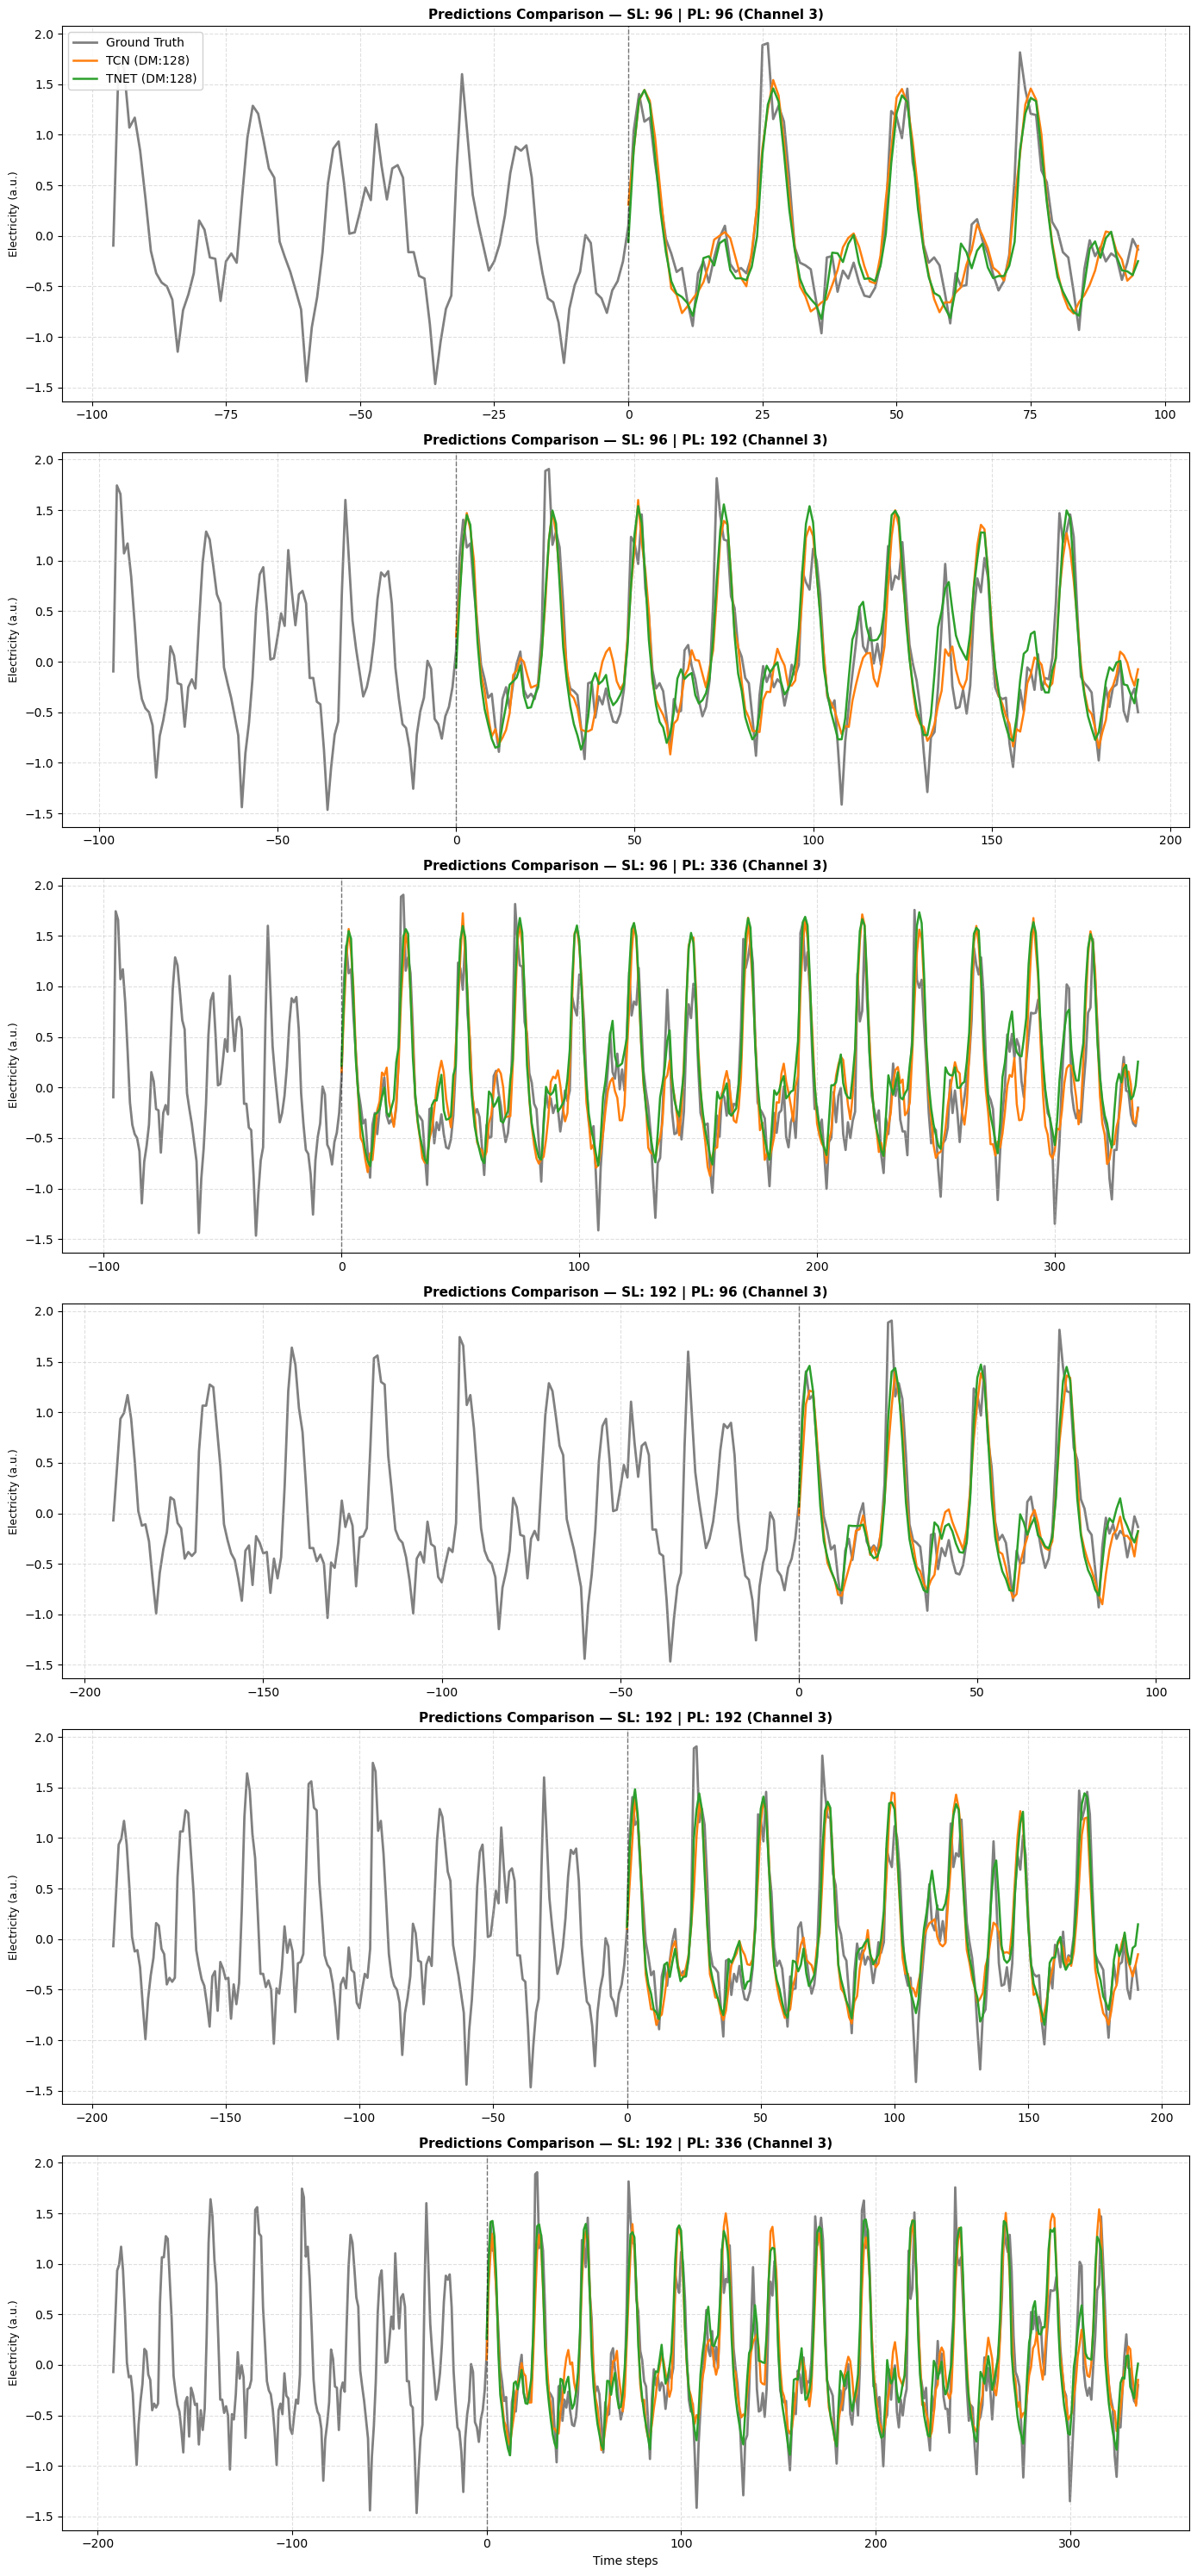

In [48]:
# --- Setup parameters ---
seq_lengths = [96, 192]
pred_lengths = [96, 192, 336]
d_models = [128]
channel = 3
sample_idx = 0
models = [("TCN", "TCN"), ("TimesNet", "TNET")]

# 4 Model configurations to compare on each plot
model_configs = []
for dm in d_models:
    for model_folder, label in models:
        model_configs.append((model_folder, label, dm))

# 6 (sl, pl) hyperparameter pairs -> 6 rows
param_pairs = list(itertools.product(seq_lengths, pred_lengths))
num_rows = len(param_pairs)

# Distinct colors for the 4 model predictions
model_colors = ["#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]  # Orange, Green, Red, Purple

# --- Plotting ---
fig, axs = plt.subplots(
    num_rows, 1, figsize=(14, 5 * num_rows), sharey=False
)
if num_rows == 1:
    axs = [axs]

for r, (sl, pl) in enumerate(param_pairs):
    ax = axs[r]
    is_first_plot = r == 0
    is_last_plot = r == num_rows - 1

    gt_plotted = False  # Track ground truth plotting

    for m_idx, (model_folder, label, dm) in enumerate(model_configs):
        root_path = f"./checkpoints/{model_folder}_sl{sl}_pl{pl}_dm{dm}_el2_tk5/"

        input_path = os.path.join(root_path, "sample_input.npy")
        true_path = os.path.join(root_path, "sample_true.npy")
        pred_path = os.path.join(root_path, "sample_pred.npy")

        try:
            inputs = np.load(input_path)
            trues = np.load(true_path)
            preds = np.load(pred_path)

            x_input = inputs[sample_idx, :, channel]  # [seq_len]
            x_true = trues[sample_idx, :, channel]  # [pred_len]
            x_pred = preds[sample_idx, :, channel]  # [pred_len]

            seq_len = len(x_input)
            pred_len = len(x_pred)

            t_future = np.arange(0, pred_len)

            # Plot Ground Truth ONCE per row
            if not gt_plotted:
                full_true = np.concatenate([x_input, x_true])
                t_full = np.arange(-seq_len, pred_len)

                ax.plot(
                    t_full,
                    full_true,
                    color="gray",
                    linewidth=2,
                    label="Ground Truth",
                    zorder=1,
                )
                gt_plotted = True

            # Plot Model Prediction
            ax.plot(
                t_future,
                x_pred,
                color=model_colors[m_idx],
                linewidth=1.8,
                label=f"{label} (DM:{dm})",
                zorder=2,
            )

        except FileNotFoundError:
            print(
                f"Missing checkpoint: {model_folder}_sl{sl}_pl{pl}_dm{dm}_el2_tk5"
            )

    # Vertical split line at prediction start
    ax.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)

    # Style each row subplot
    ax.set_title(
        f"Predictions Comparison — SL: {sl} | PL: {pl} (Channel {channel})",
        fontsize=11,
        fontweight="bold",
    )
    ax.set_ylabel("Electricity (a.u.)", fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)

    if is_last_plot:
        ax.set_xlabel("Time steps", fontsize=10)

    # Show legend only on the first row plot
    if is_first_plot:
        ax.legend(
            loc="upper left", frameon=True, facecolor="white", framealpha=0.9
        )

plt.tight_layout()
plt.savefig("all_predictions_comparison.png", bbox_inches="tight", dpi=300)
plt.show()

In [56]:
# debug:
# min{max{2^ceil(log C) , d_min }, d_max } 
import math
C= 321
d_min = 32
d_max = 512
result = min(max(2 ** math.ceil(math.log2(C)), d_min), d_max)
result

512